# Preprocessing, clustering and annotation workflow

This notebook introduces a basic exploration workflow on the PBMC3K dataset. PBMC3K is small enough to load into memory, but here it is used as a compact teaching example for the same on-disk workflow that scAtlasPy applies to much larger atlases.

By the end of this tutorial, you will be able to:

- create an Atlas database from an h5ad file;
- run quality control, filtering, normalization, HVG selection, and scaling;
- build a read index for downstream analysis;
- compute PCA, KMeans clusters, and UMAP coordinates;
- visualize QC metrics, embeddings, and marker-gene expression;
- rank marker genes and add a simple manual cell-type annotation.

The central object is an `Atlas`: a persistent `.sasql` database that stores the expression matrix, cell and gene metadata, filtered analysis views, embeddings, cluster labels, marker statistics, and annotation results. The user-facing workflow stays close to established single-cell analysis in Python, while the data and intermediate results remain queryable on disk rather than being held entirely in memory.

This tutorial starts from `data/pbmc3k.h5ad`, creates a temporary atlas file `tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql`, and then runs quality control, preprocessing, PCA, Clustering, UMAP, marker-gene ranking, and cell-type annotation.

## 1. Setup

Run this notebook in an environment where scAtlasPy and its documentation dependencies are installed. In this repository, the validated development environment is `scatlaspy-dev`.

The first cell resolves the repository root, locates `data/pbmc3k.h5ad`, and creates a clean temporary `.sasql` database for the tutorial. Re-running the notebook will replace only this tutorial database; it will not modify the source h5ad file.

In [1]:
from pathlib import Path
import warnings
import os

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import scatlaspy as sap

In [2]:
# Keep tutorial outputs focused on the workflow rather than non-critical messages.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Hide progress bars in the rendered notebook.
sap.set_progress(False)

# Change to the repository root so the relative paths below resolve.
os.chdir(Path("~/scAtlaspy-code-analysis").expanduser())

data_path = Path(f"./data/pbmc3k.h5ad")
db_path = Path(f"./tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql")

# Create the output directory and remove any previous tutorial database.
db_path.parent.mkdir(parents=True, exist_ok=True)
if db_path.exists():
    db_path.unlink()

print(f"data: {data_path}")
print(f"database: {db_path}")

data: data/pbmc3k.h5ad
database: tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql


## 2. Create an Atlas database

`load_h5ad()` imports the expression matrix and metadata into a DuckDB-backed Atlas database. The database is a normal file with the `.sasql` suffix, so it can be closed, reopened, queried, and used as the persistent record of the analysis.

This example uses `load_type="random"`, matching the randomized block-import path used for larger datasets. For small data where preserving the exact h5ad cell order is important, `load_type="order"` is also available.

scAtlasPy automatically detects whether the source matrix contains count-scale or log-transformed values and always stores expression data on the count scale in the Atlas. Normalization and log transformation should be performed after import using the `sap.pp` preprocessing functions.

```{note}
`db_memory_limit` controls the memory available to DuckDB for database queries,
imports, and intermediate database operations. It is not a global memory limit
for all of scAtlasPy, Python, NumPy, pandas, or plotting code. A more permissive
DuckDB memory limit can reduce repeated disk access and improve performance when
adequate system memory is available. The default is `db_memory_limit=None`, which
leaves memory management to DuckDB's own engine instead of applying an explicit
limit.
```

In [ ]:
atlas = sap.Atlas(db_path, db_memory_limit="8GB")
atlas.load_h5ad(data_path, load_type="random")

print(atlas)

## 3. Quality control

The QC functions compute standard per-cell and per-gene summaries inside the Atlas database. `filter_cells()` and `filter_genes()` mark cells and genes that pass the selected thresholds; they do not physically delete rows from the atlas. This makes threshold changes cheap because the original imported data remain available.

The plots below give the same checks a user would perform in an in-memory Scanpy workflow: highly expressed genes, distributions of QC metrics, and relationships among counts, detected genes, and mitochondrial content.

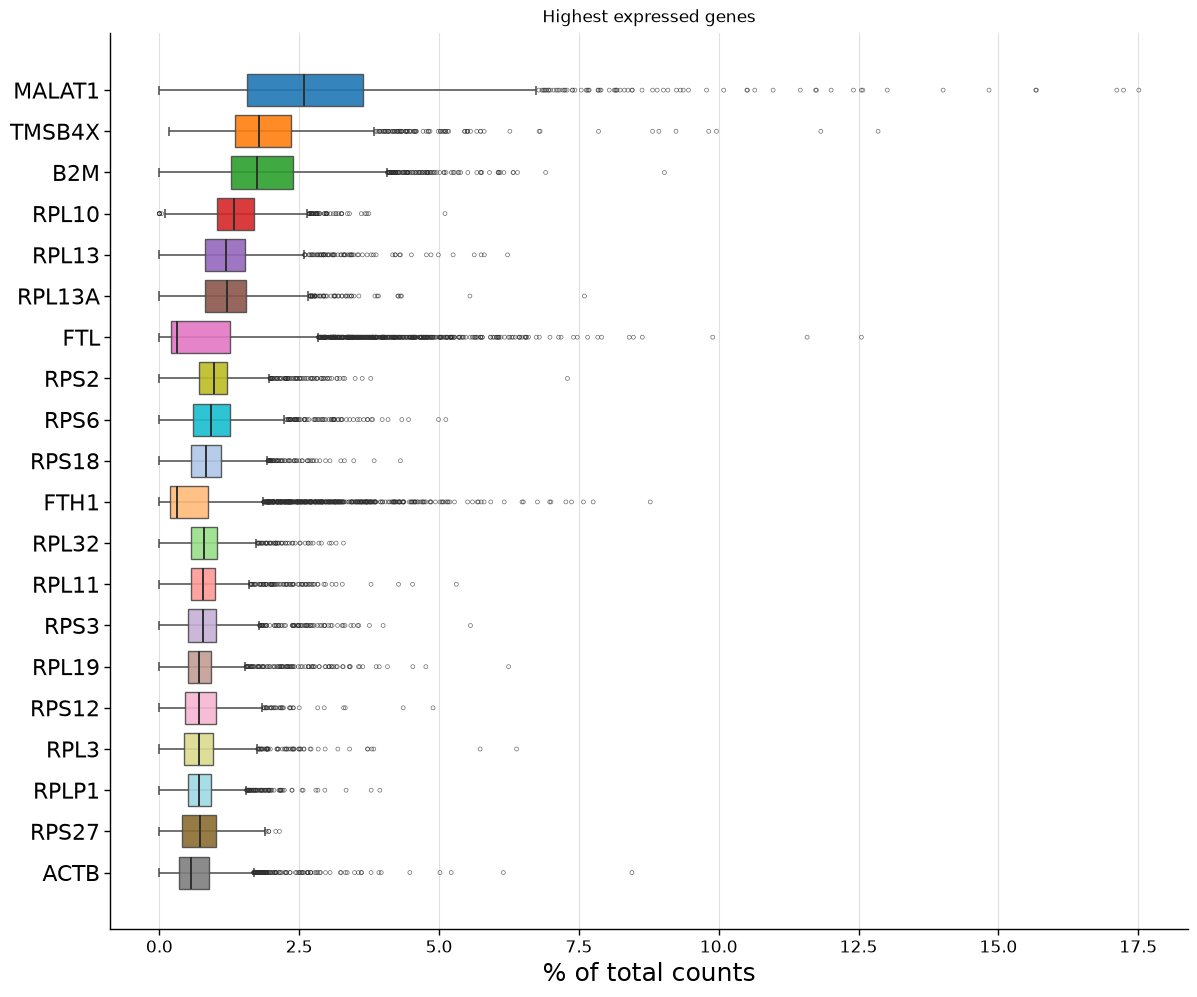

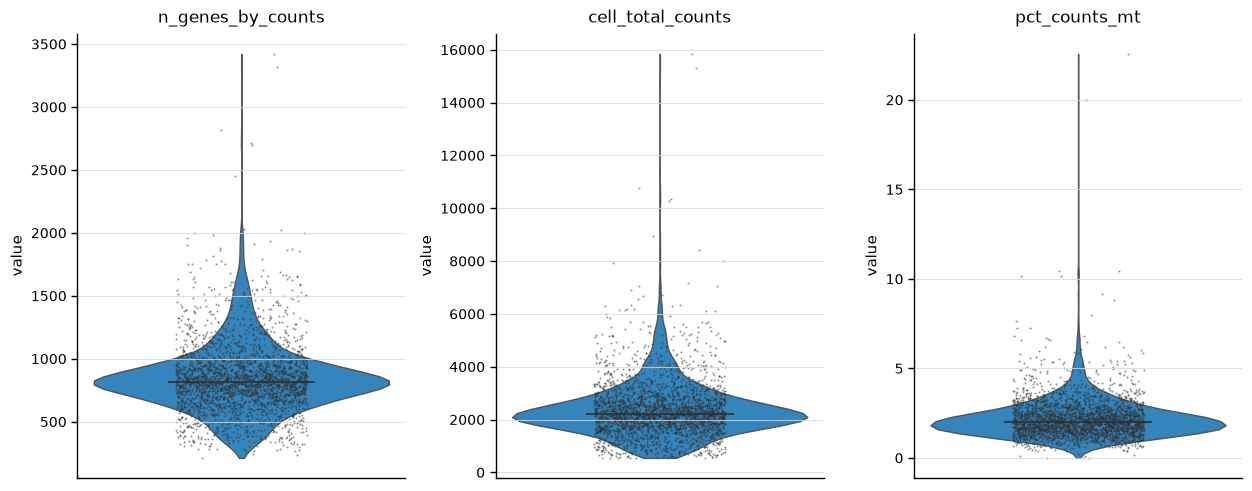

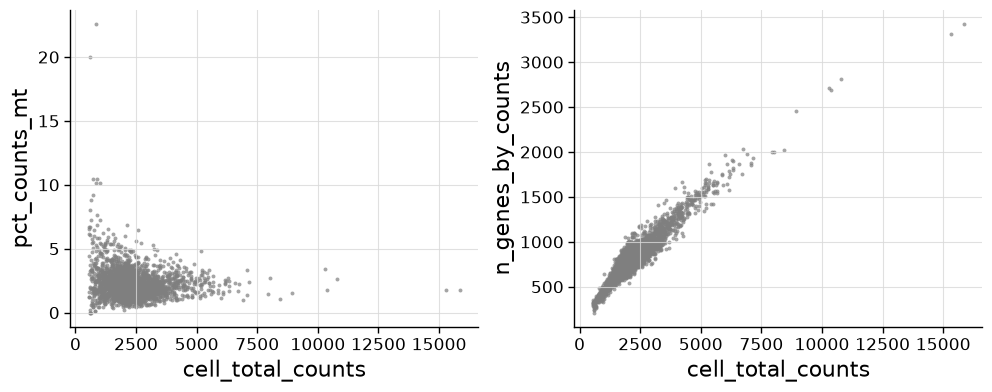

In [4]:
# Inspect whether a few genes dominate the count distribution.
sap.pl.highest_expr_genes(atlas, n_top=20)

# Apply basic cell and gene filters before downstream analysis.
sap.pp.filter_cells(atlas, min_genes=200)
sap.pp.filter_genes(atlas, min_cells=3)

# Compute and visualize standard per-cell QC metrics.
sap.pp.calculate_qc_metrics(atlas)
sap.pl.violin_qc_metrics(atlas)
sap.pl.scatter_qc_metrics(atlas)

## 4. Normalize and log-transform counts

scAtlasPy stores multiple expression fields side by side in the sparse expression table. In this workflow, raw counts remain in `data`, and library-size-normalized, log1p-transformed values are written to `data_log1p`.

In [ ]:
sap.pp.normalize_and_log1p(atlas, target_sum=1e4)

## 5. Select highly variable genes

`highly_variable_genes()` writes a Boolean marker to the `var` table. These genes define a compact feature set for PCA and clustering.

```{note}
Use the same `flavor` when plotting highly variable genes as you used when computing them. For example, after `flavor="seurat"`, call `sap.pl.highly_variable_genes(..., flavor="seurat")`.
```

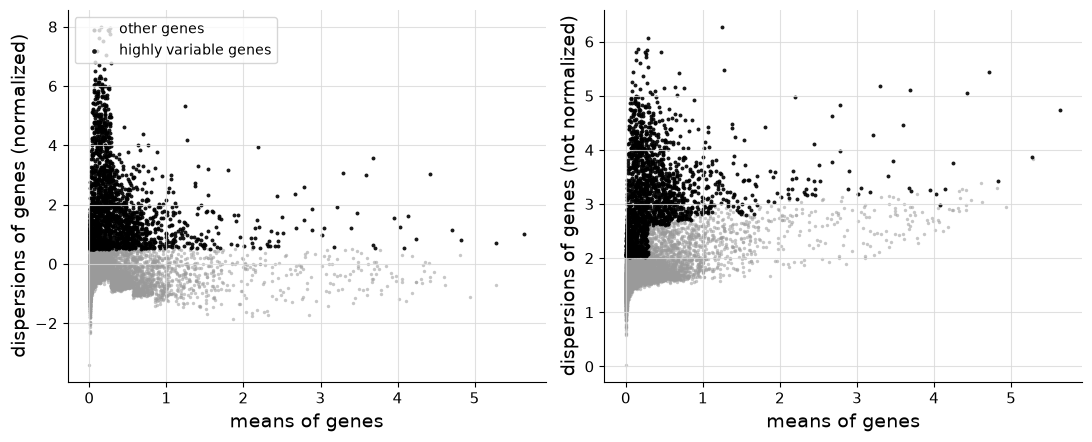

In [6]:
sap.pp.highly_variable_genes(atlas, flavor="seurat")
sap.pl.highly_variable_genes(atlas, flavor="seurat")

## 6. Scale data

Scaling writes z-scored values to `data_scale`, which is commonly used before PCA and clustering.

```{tip}
scAtlasPy stores z-scored data with the same highly efficient HyS sparse-compressed layout used for expression matrices. Scaling therefore does not cause a storage blow-up from turning many implicit zeros into explicit nonzero values.
```

In [7]:
sap.pp.scale(atlas)

## 7. Build the read index

`build_read_index()` combines cell filters, gene filters, the HVG flag, and the selected expression field into a compact analysis view for efficient traversal. Downstream routines can then quickly iterate over this view in minibatches instead of materializing the complete matrix in memory.

The `use_data` setting controls which expression field is read when a routine traverses the dataset to fit a model. For example, KMeans reads minibatches from this indexed view during training. This tutorial uses `data_scale`, but you can build the read index from `data_log1p` instead if that is the representation you want model-training routines to iterate over.

In [8]:
atlas.build_read_index(
    use_hvg=True,
    use_data="data_scale"
)

## 8. PCA

PCA reads the matrix defined by the current read index. In this workflow, the read index was built from scaled HVGs, but the same PCA API can be applied to another analysis view if you build the read index with a different `use_data` or feature selection.

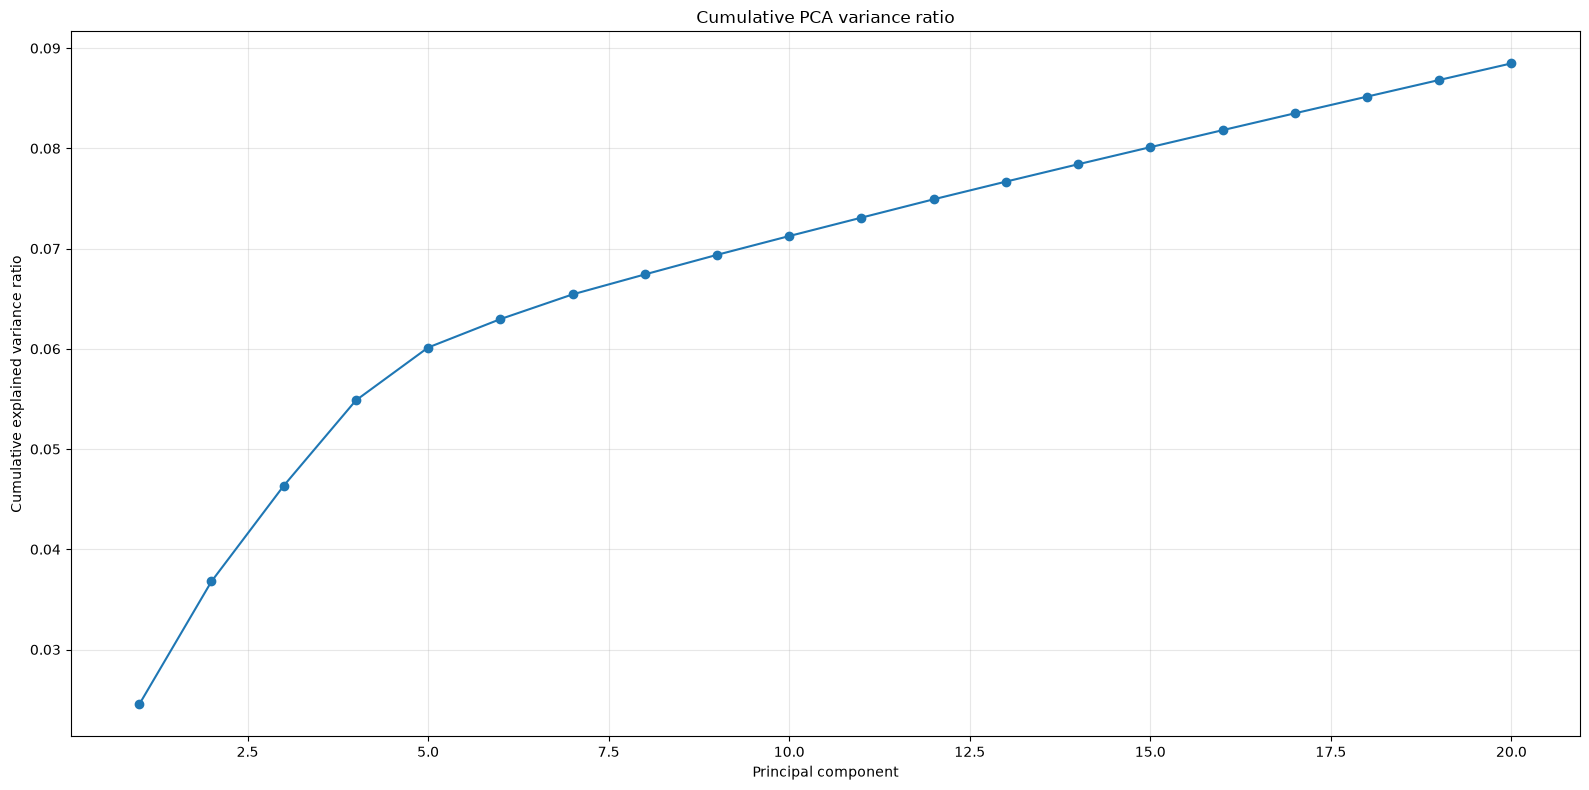

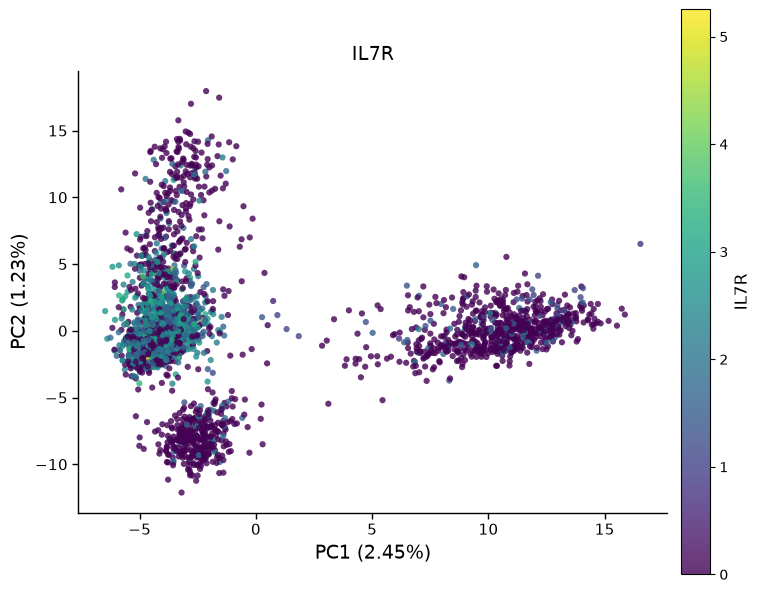

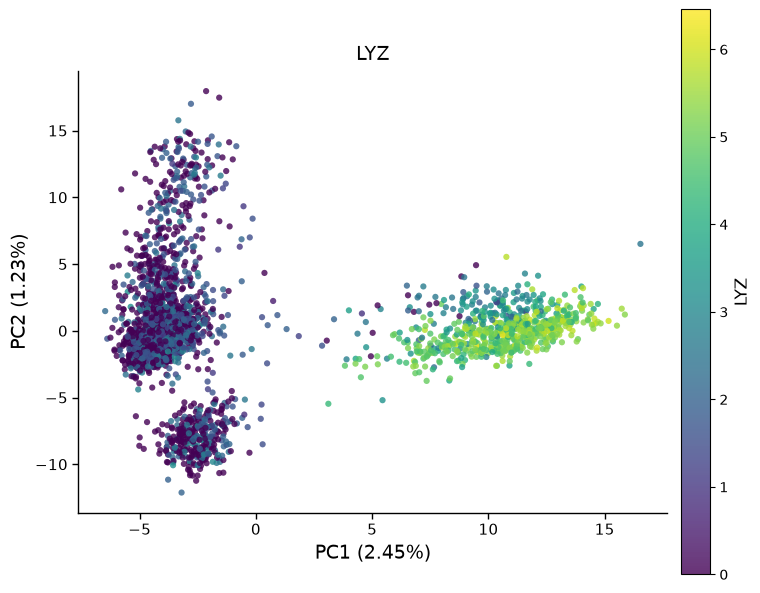

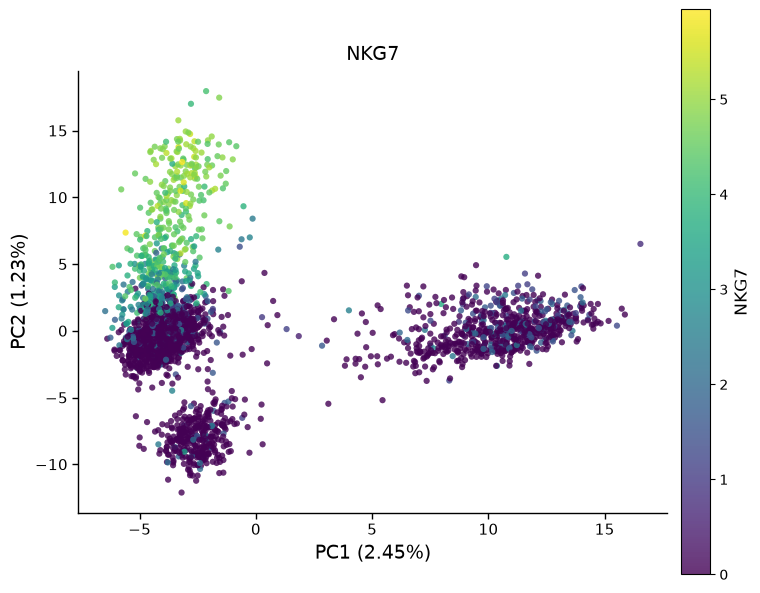

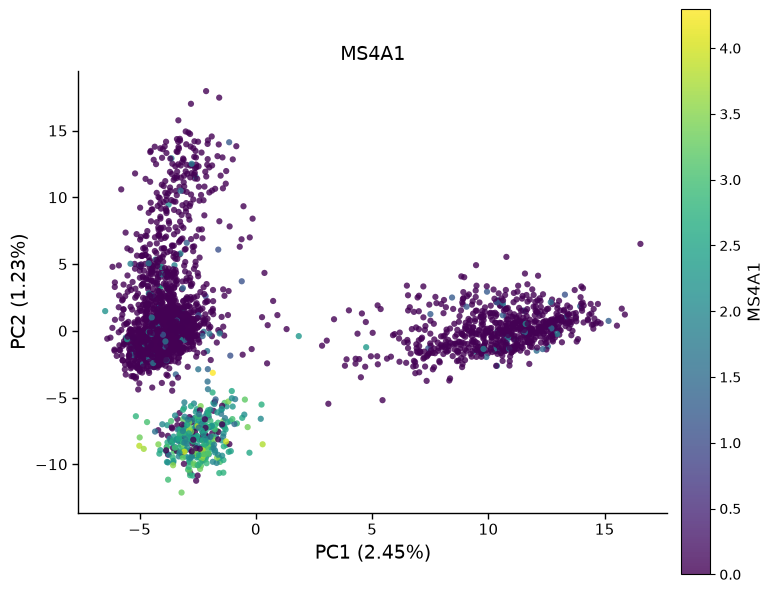

In [9]:
sap.tl.pca(atlas, n_components=30, fit_batches=60, batch_size=1024)
sap.pl.pca_variance_ratio_cumsum(atlas, n_pcs=20)

# Color PC1/PC2 by canonical PBMC marker genes.
for marker_gene in ["IL7R", "LYZ", "NKG7", "MS4A1"]:
    sap.pl.pca(
        atlas,
        color=marker_gene,
        x_pc=0,
        y_pc=1,
        use_data="data_log1p",
        sample_n=None,
        point_size=20,
        figsize=(8, 6),
    )

```{note}
`fit_batches` controls how many minibatches are used to fit the streaming PCA model. Atlases with rich cellular heterogeneity or diverse functional states usually benefit from more fitting batches so that the model sees a broader range of cell states during training. `batch_size` controls how many cells are included in each minibatch; larger minibatches carry more information per update and can make each fitting step more stable. These parameters mainly affect statistical coverage and fitting stability, and are not usually the primary source of memory pressure.
```

## 9. KMeans

KMeans clusters cells in the PCA space and writes the labels back to `obs`. The PC1/PC2 scatter plot below uses the resulting `kmeans` labels to show how the clusters are arranged in the leading PCA dimensions.

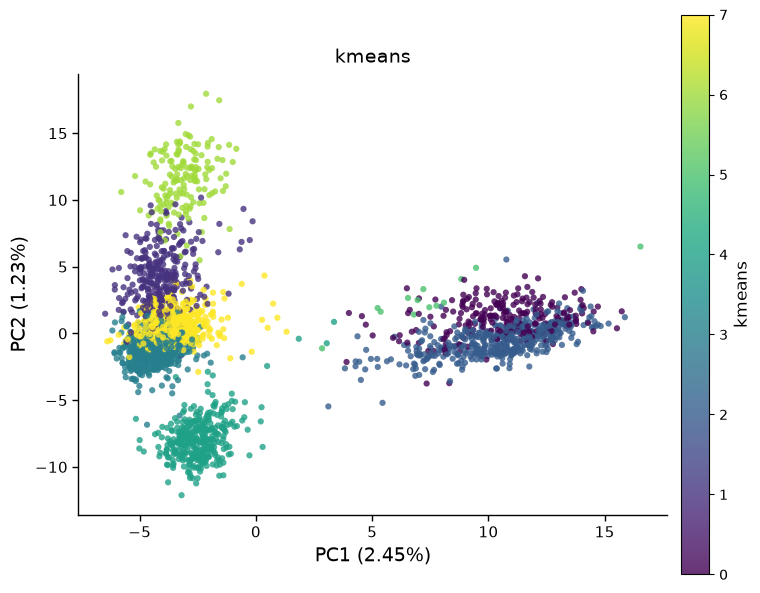

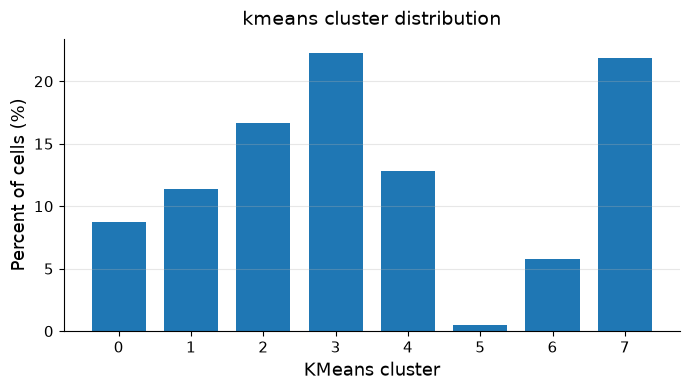

In [10]:
sap.tl.kmeans(
    atlas,
    n_components=20,
    n_clusters=8,
    batch_size=1024,
    fit_batches=80,
    add_obs_col="kmeans",
)

sap.pl.pca(
    atlas,
    color="kmeans",
    x_pc=0,
    y_pc=1,
    sample_n=None,
    point_size=20,
    figsize=(8, 6),
)

sap.pl.kmeans_cluster_size(atlas, use_obs_col="kmeans")

## 10. UMAP

UMAP is computed from the PCA coordinates stored in `obsm_X_pca` and written back to the Atlas database as `obsm_X_umap`. Plotting functions read the stored embedding and can color cells by cluster labels or other metadata columns.

In [11]:
umap=sap.tl.umap(
    atlas,
    fit_sample_n=None,
    n_pcs=20,
    n_neighbors=30,
    min_dist=0.3,
    eval_sample_n=1000,
)

In [ ]:
sap.pl.umap(
    atlas,
    color="kmeans",
    legend_loc="on_data",
    sample_n=None,
    point_size=20,
    figsize=(8, 6),
)

Marker-gene UMAPs show how expression fields can be selected explicitly with `use_data`. Here, `data_log1p` is used for interpretable marker expression.

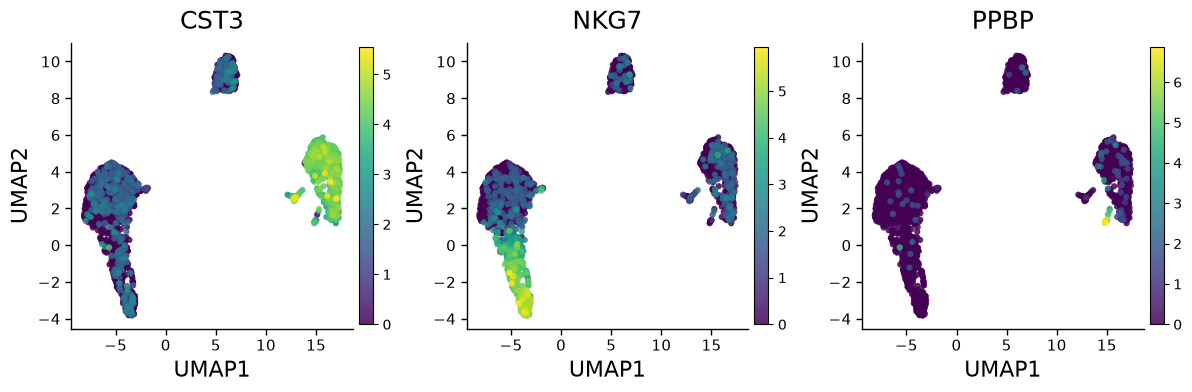

{'CST3':       atlas_cell_id      umap1     umap2      expr
 0              1550   4.990669  9.197793  0.000000
 1              1573  -3.672597  2.695674  0.000000
 2              1572  -6.680637  2.780682  0.000000
 3              1570  -4.255785  1.519701  0.000000
 4              1569  -6.664770  3.415878  0.000000
 ...             ...        ...       ...       ...
 2695           1713  12.824731  2.559514  5.355943
 2696           2244  15.876100  3.916241  5.363081
 2697            723  16.120050  2.693195  5.427814
 2698           2355  16.998583  2.536724  5.533453
 2699           1182  16.409788  3.453920  5.550671
 
 [2700 rows x 4 columns],
 'NKG7':       atlas_cell_id     umap1     umap2      expr
 0              2163 -3.357638  3.041521  0.000000
 1              2200 -5.941738  3.078405  0.000000
 2              2151 -6.066734  2.902221  0.000000
 3              2150 -4.880742  0.125104  0.000000
 4              2149  5.107886  8.781360  0.000000
 ...             ...      

In [13]:
sap.pl.umap(
    atlas,
    color=["CST3", "NKG7", "PPBP"],
    use_data="data_log1p",
    sample_n=None,
    point_size=20,
    figsize=(12, 4),
)

## 12. Rank marker genes

`rank_genes_groups()` computes marker statistics for each cluster and stores the result in the Atlas database. The returned table can be inspected directly, plotted with scAtlasPy, or used to support manual annotation.

KMeans labels are an unsupervised grouping, not cell types. Marker ranking provides the evidence needed to interpret those groups biologically.

In [14]:
rank_result = sap.tl.rank_genes_groups(
    atlas,
    groupby="kmeans",
    use_data="data_log1p",
    add_table = "rank_genes_groups"
)
rank_result.head()

,group,reference,rank,atlas_gene_id,names,scores,logfoldchanges,pvals,pvals_adj,mean_in,mean_ref,pct_nz_in,pct_nz_ref,n_in,n_ref,method
0,0,rest,0,28817,CST3,64.980996,4.910394,0.000000e+00,0.000000e+00,3.961806,0.998511,1.000000,0.340503,236,2464,t-test
1,0,rest,1,25892,COTL1,58.387370,3.642449,1.769594e-272,2.896649e-268,3.644463,1.382258,1.000000,0.589692,236,2464,t-test
2,0,rest,2,2224,FCER1G,56.661802,4.636878,1.334745e-209,1.092422e-205,3.379440,0.760653,1.000000,0.295455,236,2464,t-test
3,0,rest,3,10610,AIF1,56.241548,4.679710,1.814452e-207,1.188031e-203,3.469039,0.794663,0.995763,0.313718,236,2464,t-test
4,0,rest,4,10608,LST1,56.033414,4.924174,4.995296e-193,2.725600e-189,3.522884,0.733816,0.995763,0.293831,236,2464,t-test


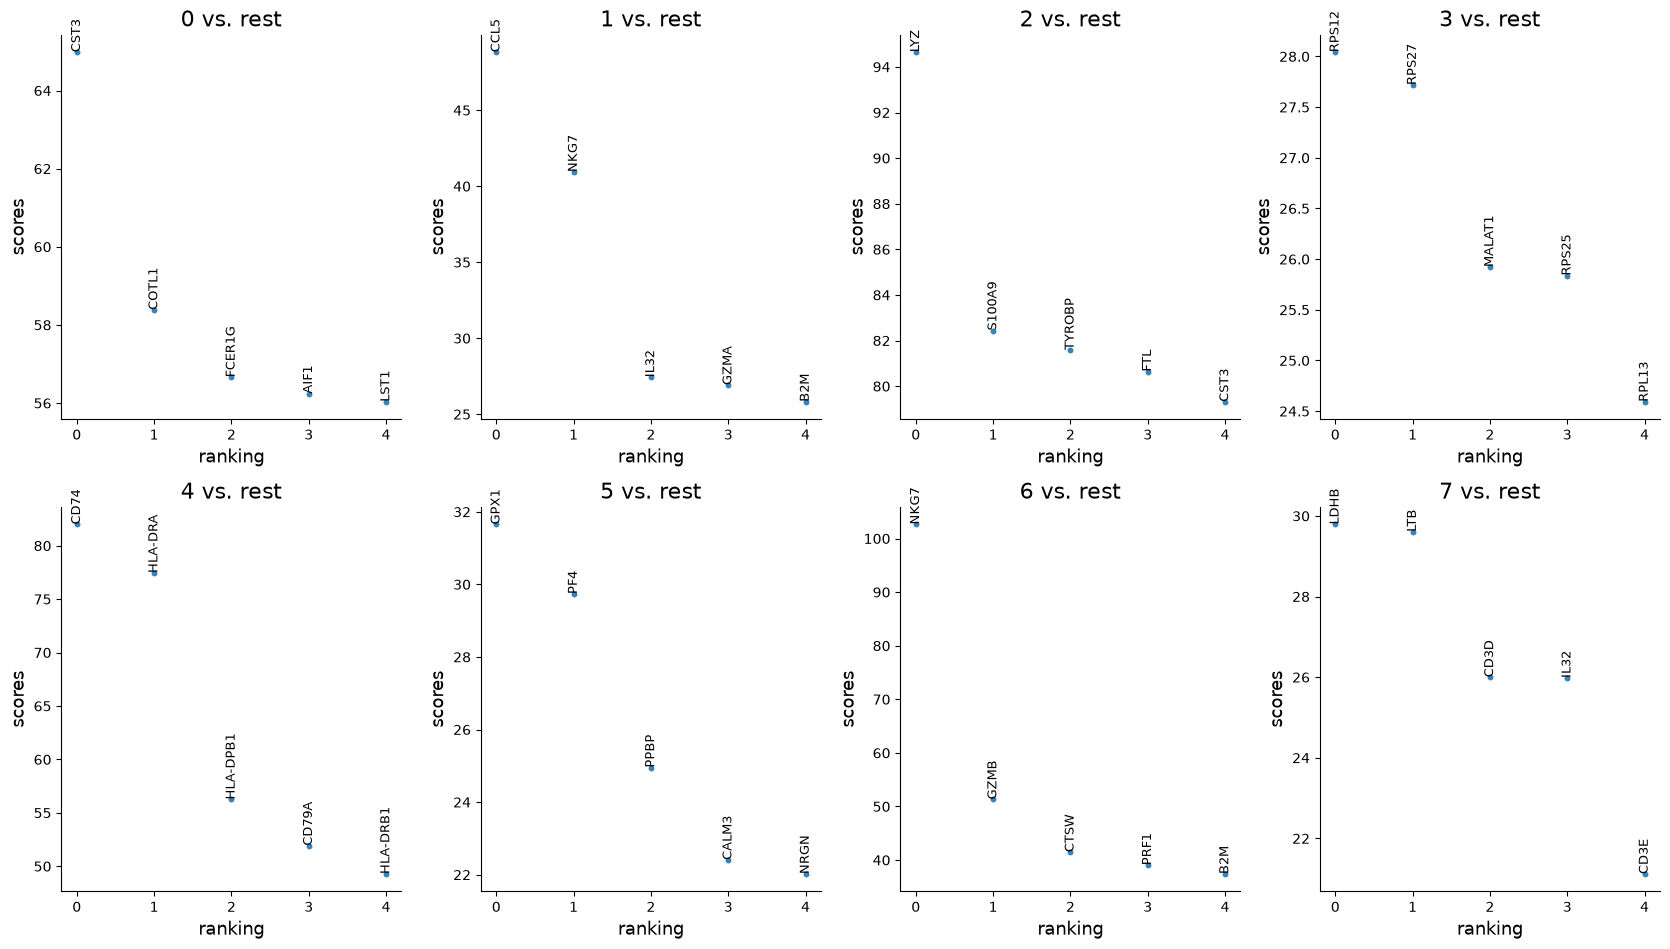

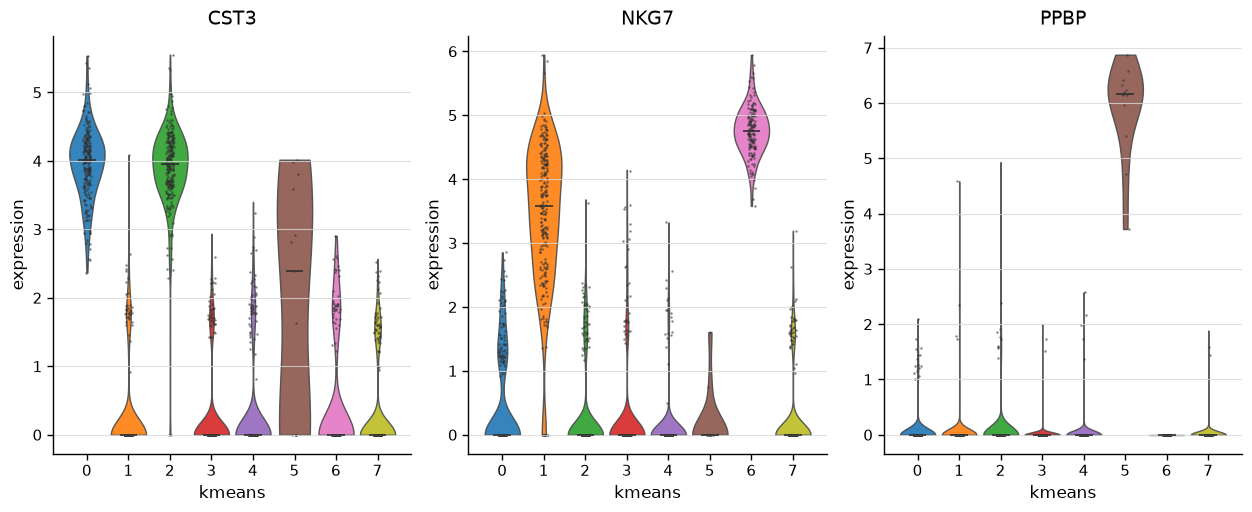

In [16]:
sap.pl.rank_genes_groups(atlas, n_genes=5)
sap.pl.violin(atlas, genes=["CST3", "NKG7", "PPBP"], groupby="kmeans")

## 13. Manual annotation

The mapping below assigns human-readable cell-type labels to KMeans clusters after marker inspection. In a real analysis, this step should be adjusted using the marker-gene rankings, UMAP expression patterns, sample metadata, and domain knowledge.

`manual_annotate_clusters()` writes the labels to a new `obs` column, here `cell_type_manual`, and records the mapping in a separate annotation table so that the interpretation is preserved with the atlas.

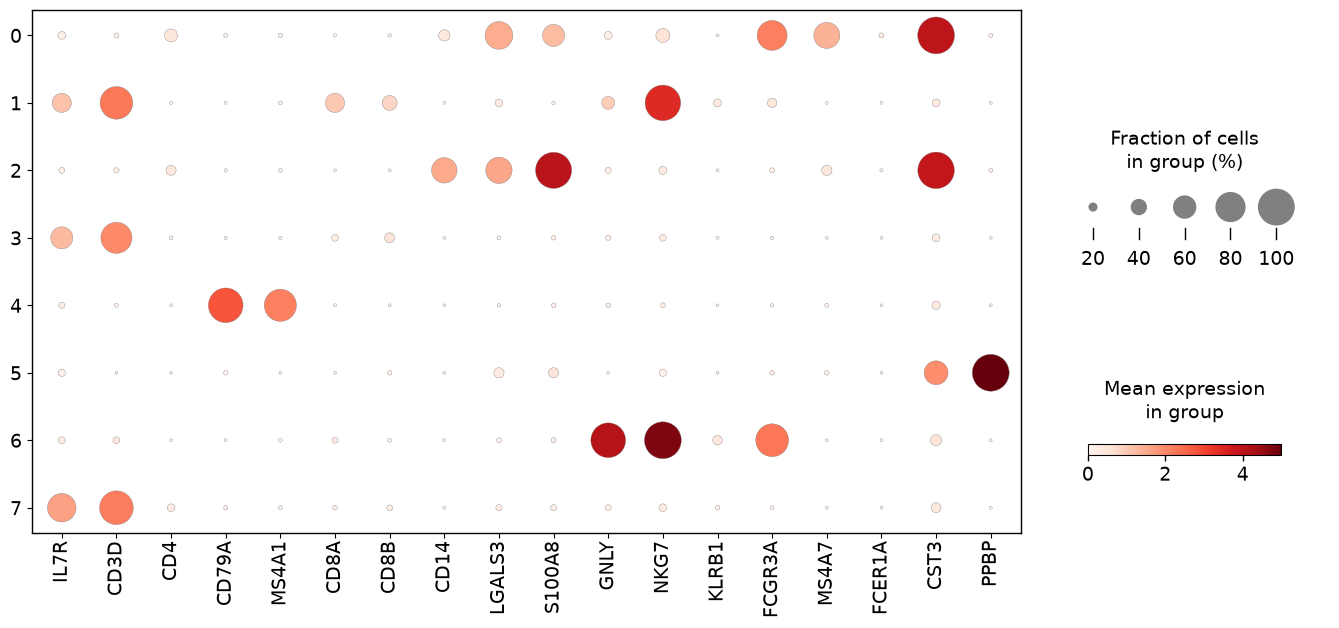

In [15]:
marker_genes = [
    "IL7R",
    "CD3D",
    "CD4",
    "CD79A",
    "MS4A1",
    "CD8A",
    "CD8B",
    "CD14",
    "LGALS3",
    "S100A8",
    "GNLY",
    "NKG7",
    "KLRB1",
    "FCGR3A",
    "MS4A7",
    "FCER1A",
    "CST3",
    "PPBP",
]

dotplot_stats = sap.pl.dotplot(
    atlas,
    genes=marker_genes,
    groupby="kmeans",
    use_data="data_log1p",
)

In [21]:
mapping = {
    "0": "FCGR3A+ Monocytes",
    "1": "NKT",
    "2": "CD14+ Monocytes",
    "3": "CD8 T",
    "4": "B",
    "5": "Megakaryocytes",
    "6": "NK",
    "7": "CD4 T",
}

summary = sap.tl.manual_annotate_clusters(
    atlas,
    cluster_to_cell_type=mapping,
    groupby="kmeans",
    obs_col="cell_type_manual",
    table_name="manual_cluster_annotation",
)

summary

,cluster_id,cell_type,n_cells
0,0,FCGR3A+ Monocytes,236
1,1,NKT,307
2,2,CD14+ Monocytes,449
3,3,CD8 T,602
4,4,B,347
5,5,Megakaryocytes,13
6,6,NK,156
7,7,CD4 T,590


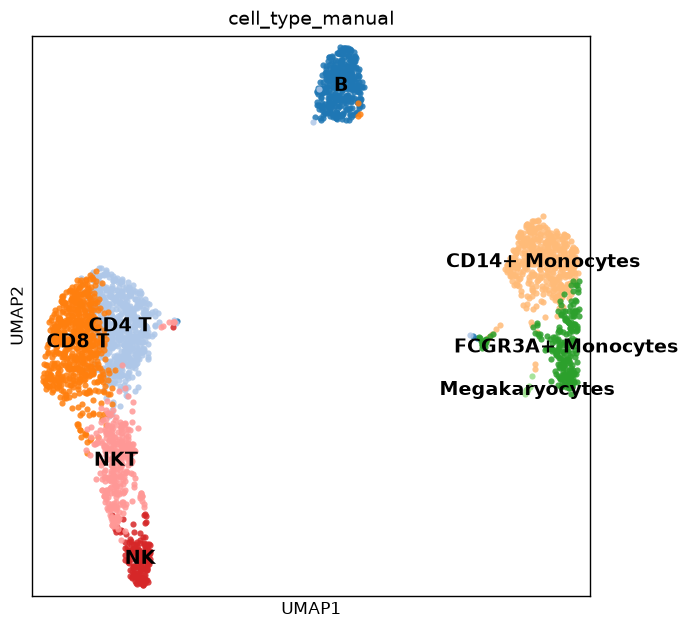

In [22]:
sap.pl.umap(
    atlas,
    color="cell_type_manual",
    legend_loc="on_data",
    sample_n=None,
    point_size=20,
    figsize=(9, 7),
)

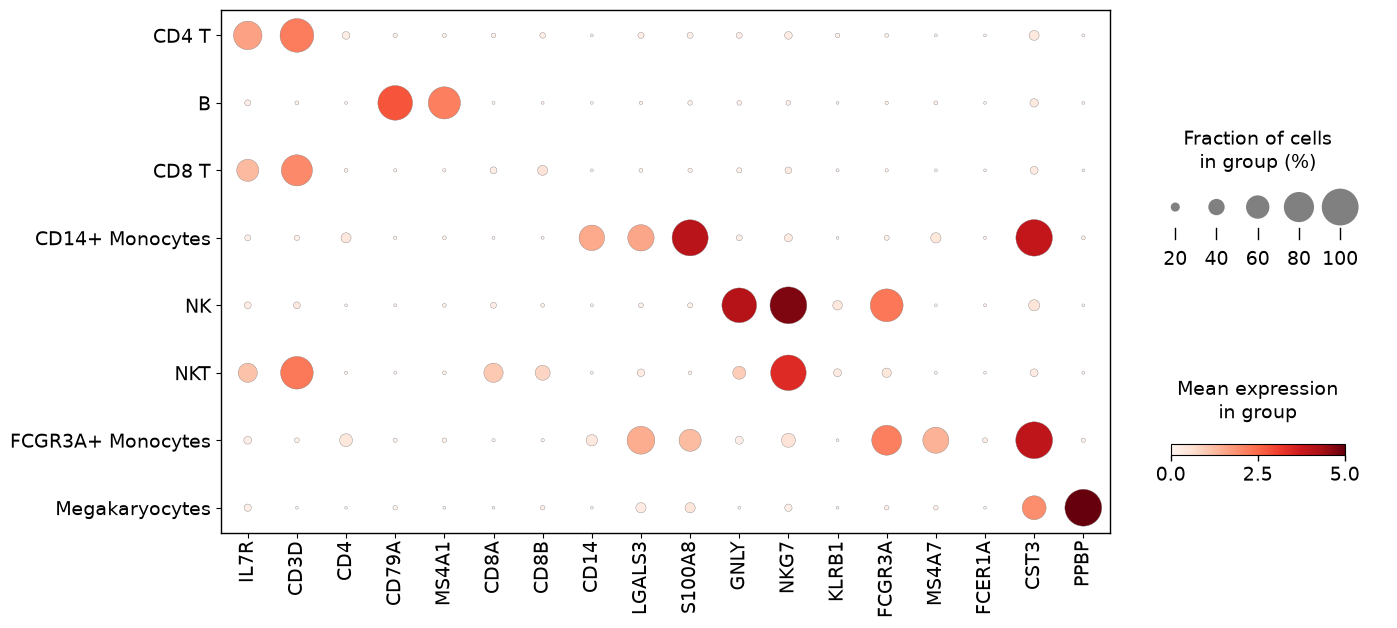

In [23]:
dotplot_stats = sap.pl.dotplot(
    atlas,
    genes=marker_genes,
    groupby="cell_type_manual",
    use_data="data_log1p",
    order=["CD4 T", "B", "CD8 T", "CD14+ Monocytes", "NK", "NKT", "FCGR3A+ Monocytes","Megakaryocytes"]
)

## 14. Close the database

Close the Atlas connection when the workflow is complete. The `.sasql` file remains on disk and can be reopened later for additional analysis, SQL queries, export to AnnData, or method development.

In [24]:
print(atlas.describe())
atlas.close()

file_name       : /home/hanxu/scAtlaspy-code-analysis/tmp/tutorials/basic_pbmc3k/pbmc3k_basic.sasql
db_memory_limit : 8GB
tables          : 17
table names     : X_HyS_data, X_HyS_data_filtered, X_HyS_indptr, X_HyS_indptr_filtered, atlas_read_index_meta, kmeans_centers, manual_cluster_annotation, obs, obs_cluster, obsm_X_pca, obsm_X_umap, rank_genes_groups, uns_pca_stats, uns_umap_eval, uns_umap_params, var, varm_PCs
n_cells         : 2,700
n_genes         : 32,738
